K maean clusterization

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [3]:
from sklearn.datasets import make_blobs

In [4]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=42)

In [5]:
X

array([[-6.59633932, -7.13901457],
       [-6.13753182, -6.58081701],
       [ 5.19820575,  2.04917508],
       ...,
       [ 3.69047995,  4.60555175],
       [ 4.03036663,  1.78619838],
       [-7.44179522, -7.08933147]])

In [6]:
y

array([2, 2, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 1, 2,
       2, 2, 1, 0, 0, 0, 1, 1, 2, 2, 1, 0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 2,
       0, 2, 0, 0, 2, 1, 2, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 0, 2, 2, 0, 0,
       2, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 0, 0, 0, 1, 0, 0, 0, 1, 2, 1, 2,
       0, 0, 0, 0, 1, 1, 2, 1, 2, 0, 1, 1, 1, 2, 2, 0, 2, 1, 1, 0, 1, 0,
       2, 1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 2, 1, 2, 2, 1, 2, 1, 1, 0, 1,
       1, 2, 0, 2, 0, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 0, 0, 0, 0, 2, 1, 2,
       0, 1, 0, 1, 0, 2, 1, 0, 0, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 1, 0, 2,
       1, 2, 1, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 2, 1, 1,
       1, 2, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 0, 2, 1,
       2, 2, 1, 0, 2, 0, 0, 1, 2, 0, 0, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 2,
       2, 1, 2, 0, 1, 0, 1, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 0, 2, 1,
       2, 2, 1, 0, 0, 2, 1, 0, 1, 1, 0, 2, 0, 2, 2, 1, 2, 1, 2, 1, 1, 0,
       0, 1, 0, 2, 2, 0, 1, 1, 2, 0, 1, 2, 2, 0, 2,

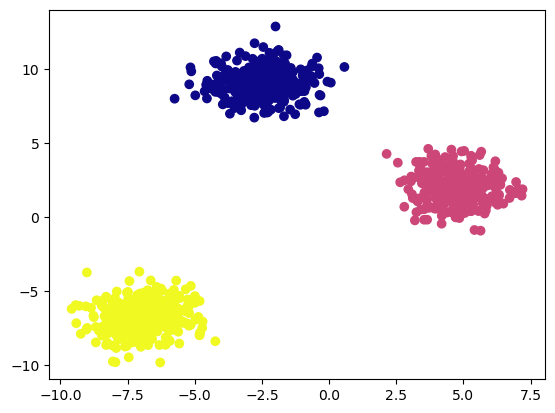

In [7]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='plasma')

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [10]:
X_train_scalar=scaler.fit_transform(X_train)
X_test_scalar=scaler.transform(X_test)

In [11]:
from sklearn.cluster import KMeans


In [12]:
#To select the number of clusters we can use the elbow method
WCSS=[] #Within cluster sum of squares
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X_train_scalar)
    WCSS.append(kmeans.inertia_)

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

In [13]:
WCSS

[1339.9999999999995,
 424.779504284127,
 43.53781728348884,
 36.75532619778977,
 30.940038308444812,
 28.529853153395585,
 23.428595054568557,
 21.475988380706582,
 19.455483512927866,
 17.417609884223136]

Text(0, 0.5, 'WCSS')

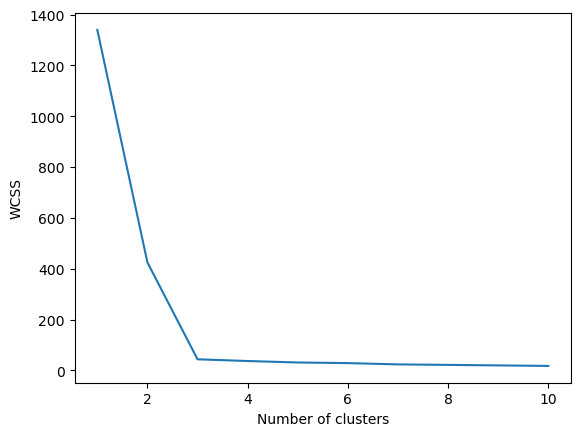

In [15]:
#plot Elbow curve
plt.plot(range(1,11),WCSS)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [16]:
kmeans=KMeans(n_clusters=3,init='k-means++',random_state=42)
y_pred=kmeans.fit_predict(X_test_scalar)


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [17]:
y_pred

array([2, 1, 1, 0, 2, 1, 0, 2, 0, 2, 2, 0, 2, 2, 2, 1, 1, 0, 1, 1, 1, 2,
       2, 0, 0, 0, 1, 2, 0, 2, 1, 0, 0, 1, 0, 0, 0, 1, 2, 0, 2, 1, 1, 0,
       2, 1, 0, 0, 2, 1, 0, 2, 2, 0, 1, 1, 2, 2, 1, 0, 0, 2, 1, 0, 1, 2,
       2, 1, 1, 2, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 2, 1, 1, 1, 0, 2, 1, 0, 2, 2, 1, 2, 1, 1, 2, 2, 1, 0,
       0, 0, 2, 1, 0, 1, 2, 2, 0, 1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 1, 0, 0,
       1, 1, 2, 1, 2, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 1, 1, 1, 0, 2, 1, 0,
       2, 2, 1, 1, 0, 0, 0, 2, 1, 0, 2, 1, 1, 2, 1, 1, 0, 2, 1, 0, 0, 0,
       2, 0, 1, 0, 2, 0, 1, 0, 0, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 1, 2,
       1, 2, 0, 2, 0, 0, 2, 2, 2, 0, 1, 2, 2, 2, 1, 0, 1, 0, 0, 2, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 2, 2, 2, 2, 0, 0, 1, 2, 1, 1, 0, 0, 1, 2, 0,
       1, 1, 1, 2, 2, 2, 0, 2, 2, 2, 0, 2, 0, 0, 2, 2, 0, 1, 1, 0, 2, 0,
       2, 1, 0, 1, 1, 0, 2, 0, 1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 2, 2, 0, 0, 0, 1, 0, 0, 0, 1,

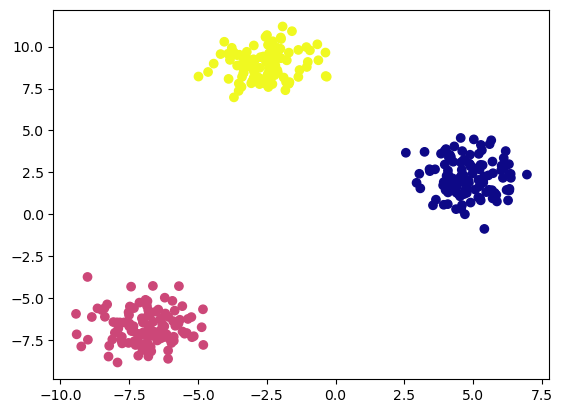

In [18]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred,cmap='plasma')

In [19]:
%pip install kneed
from kneed import KneeLocator


Note: you may need to restart the kernel to use updated packages.


In [20]:
k1=KneeLocator(range(1,11),WCSS,curve='convex',direction='decreasing')
k1.elbow

np.int64(3)

In [21]:
#silhoutte score
from sklearn.metrics import silhouette_score


In [22]:
silhoutte_coeff=[]
for i in range (2,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X_train_scalar)
    score=silhouette_score(X_train_scalar,kmeans.labels_)
    silhoutte_coeff.append(score)

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

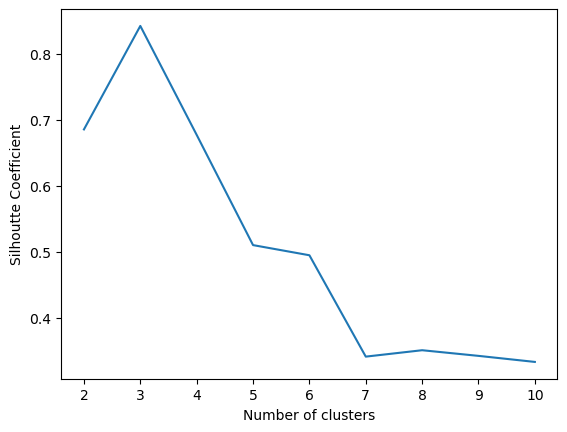

In [23]:
plt.plot(range(2,11),silhoutte_coeff)
plt.xlabel('Number of clusters')
plt.ylabel('Silhoutte Coefficient')
plt.show()
